   Gender  Annual Income (k$)  Spending Score (1-100)
0     1.0                  15                      39
1     1.0                  15                      81
2     0.0                  16                       6
3     0.0                  16                      77
4     0.0                  17                      40


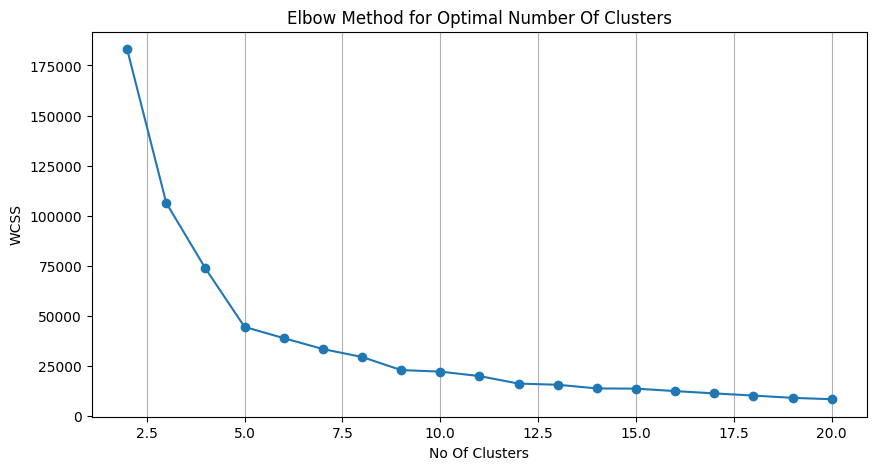

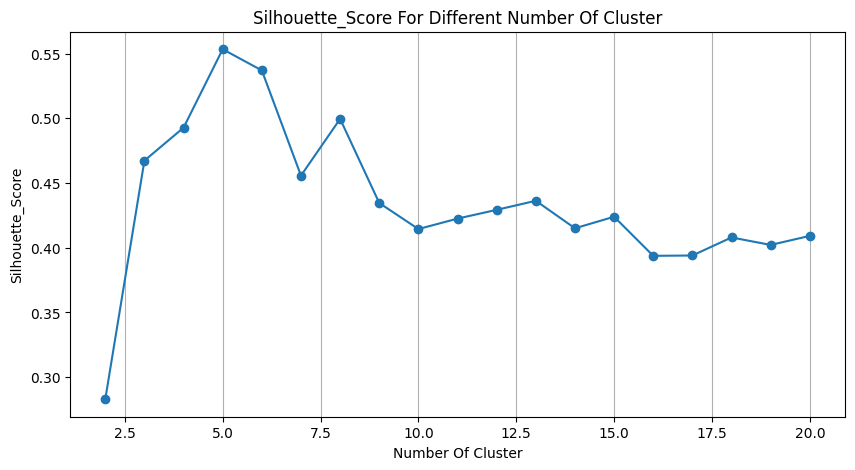

Silhouette_Score : 55.48918583460245


<Figure size 1000x500 with 0 Axes>

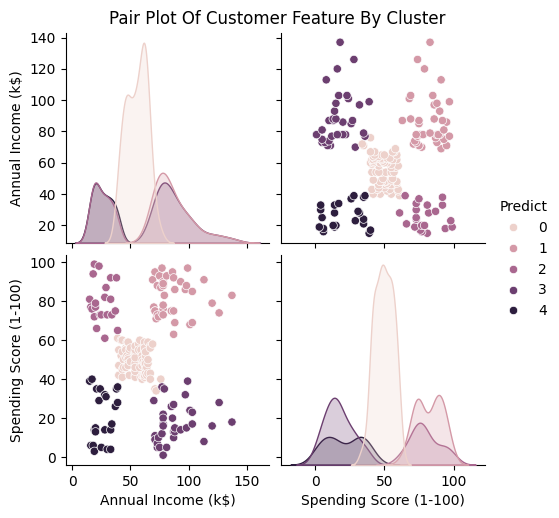

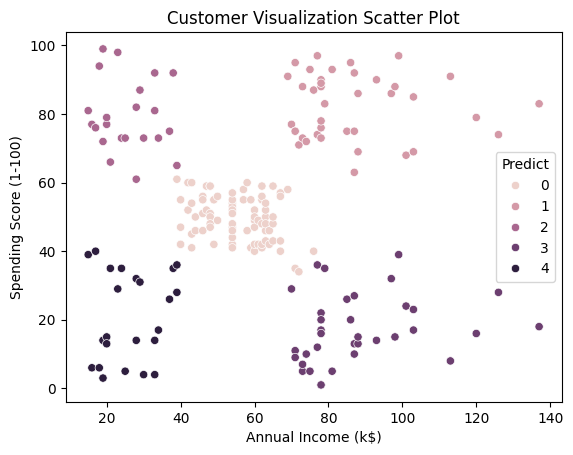

In [12]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

dataset = pd.read_csv(r"C:\Users\Saksham Awasthi\Downloads\Mall_Customers.csv")

dataset = dataset.drop(columns = ['CustomerID','Age'])

encode = OneHotEncoder(drop = 'first')
encode.fit(dataset[["Gender"]])
dataset["Gender"] = pd.DataFrame(encode.transform(dataset[["Gender"]]).toarray())
print(dataset.head(5))


wcss = []
for j in range(2,21):
    clusters = KMeans(init = 'k-means++',n_clusters = j)
    clusters.fit(dataset)
    wcss.append(clusters.inertia_)

plt.figure(figsize = (10,5))
plt.plot([i for i in range(2,21)],wcss,marker = 'o')
plt.title("Elbow Method for Optimal Number Of Clusters")
plt.xlabel("No Of Clusters")
plt.ylabel("WCSS")
plt.grid(axis = 'x')
plt.savefig("Elbow Method for Optimal Number Of Clusters",dpi = 300,bbox_inches = 'tight')
plt.show()


s_score = []
for i in range(2,21):
    model1 = KMeans(init = 'k-means++',n_clusters = i)
    labels =  model1.fit_predict(dataset)
    score1 = silhouette_score(dataset,labels)
    s_score.append(score1)

plt.figure(figsize = (10,5))
plt.plot([i for i in range(2,21)],s_score,marker = 'o')
plt.title("Silhouette_Score For Different Number Of Cluster")
plt.xlabel("Number Of Cluster")
plt.ylabel("Silhouette_Score")
plt.grid(axis = 'x')
plt.savefig("Silhouette_Score For Different Number Of Cluster",dpi = 300,bbox_inches = 'tight')
plt.show()


model = KMeans(init = 'k-means++',n_clusters = 5,random_state = 42)
Cluster = model.fit_predict(dataset)
dataset["Predict"] = Cluster
print("Silhouette_Score :",silhouette_score(dataset,Cluster)*100)

plt.figure(figsize = (10,5))
pair_plot = sns.pairplot(vars = ['Annual Income (k$)','Spending Score (1-100)'],hue = 'Predict',data =dataset)
pair_plot.figure.suptitle('Pair Plot Of Customer Feature By Cluster',y = 1.02)
plt.savefig("Pair Plot Of Customer Feature By Cluster",dpi = 300,bbox_inches = 'tight')
plt.show()


sns.scatterplot(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',data = dataset,hue = "Predict") 
plt.title("Customer Visualization Scatter Plot")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.savefig("Customer Visualization Scatter Plot.png",dpi = 300,bbox_inches = 'tight')
plt.show()
